# Chapter 5 - Main Python libraries

*This notebook contains all the sample code in Chapter 5.*


## Outline

- [Numpy](#NumPy)
    - [Arrays](#Arrays)
    - [Basic mathematical operations](#Basic_math)
    - [Randomness and linear algebra](#Randomness)
- [Matplotlib](#Matplotlib)
    - [Basic plotting](#Basic_plotting)
    - [Customizing plots](#Customizing)
    - [Subplots](#Subplots)
- [SciPy](#SciPy)
    - [Optimization](#Optimization)
    - [Signal Processing: sectral analysis](#Spectral)
    - [Signal Processing: filtering](#Filtering)

## NumPy <a id="NumPy"></a>


**NumPy** can be imported as:

In [1]:
import numpy as np

### Arrays <a id="Arrays"></a>


**Arrays** can be constructed from lists:

In [2]:
v = np.array([4, 3, 2])
A = np.array([[3, 2, 4], [3, 3, 2], [4, 5, 2]])

An array can be **displayed** by using the `print` function:

In [3]:
print(v)

[4 3 2]


In [4]:
print(*v)

4 3 2


In [5]:
print(A)

[[3 2 4]
 [3 3 2]
 [4 5 2]]


Attention that `np.zeros(N)` or `np.ones(N)` produces a linear array of shape `(N,)`!


We provide some useful examples:

In [6]:
a = np.arange(5)
print(a)

[0 1 2 3 4]


In [7]:
b = np.arange(3, 7, 2)
print(b)

[3 5]


In [8]:
c = np.ones((3, 4))
print(c)

[[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]


In [9]:
d = np.eye(3)
print(d)

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [10]:
e = np.eye(3, 4)
print(e)

[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]]


In [11]:
f = np.linspace(3, 7, 3)
print(f)

[3. 5. 7.]


In [12]:
g = np.r_[1:4, 0, 4]
print(g)

[1 2 3 0 4]


In [13]:
h = np.r_[2, 1:7:3j]
print(h)

[2. 1. 4. 7.]


In [14]:
i = np.concatenate([a, b], axis=0)

The `j` in the penultimate example specifies equally spaced points.

We provide other useful examples:

In [15]:
a = np.arange(6).reshape(3, 2)
print(a)

[[0 1]
 [2 3]
 [4 5]]


In [16]:
np.ndim(a)

2

In [17]:
np.size(a)

6

In [18]:
np.shape(a)

(3, 2)

In [19]:
np.ravel(a)

array([0, 1, 2, 3, 4, 5])

In [20]:
np.transpose(a)

array([[0, 2, 4],
       [1, 3, 5]])

In [21]:
a[::-1]

array([[4, 5],
       [2, 3],
       [0, 1]])

In [22]:
np.sum(a)

15

In [23]:
np.sum(a, axis=0)

array([6, 9])

In [24]:
np.sum(a, axis=1)

array([1, 5, 9])

Note the **use** of the `axis` option in the `sum` function (similar for `min` and `max`).


Many of these functions have an object-oriented equivalent: 

In [25]:
a.min()

0

In [26]:
a.max()

5

In [27]:
a.T

array([[0, 2, 4],
       [1, 3, 5]])

Just like the rest of Python, **NumPy** operates on object **references**:

In [28]:
c = a.copy()   # or c = np.copy(a)
print(c)

[[0 1]
 [2 3]
 [4 5]]


In order to be aware of a potential misunderstanding by using the **NumPy** library, check to the following code:

In [29]:
a = np.ones((3,3))
print(a)

[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]


In [30]:
np.shape(a)

(3, 3)

In [31]:
b = a[:,1]
print(b)

[1. 1. 1.]


In [32]:
np.shape(b)

(3,)

In [33]:
c = a[1,:]
np.shape(c)

(3,)

In [34]:
print(c)

[1. 1. 1.]


In [35]:
print(c.T)

[1. 1. 1.]


There are a few ways around the problem. Using a *slice*:

In [36]:
c = a[0:1, :]
np.shape(c)

(1, 3)

Explicitly reshaping the array:

In [37]:
c = a[0,:].reshape(1, len(a))
np.shape(c)

(1, 3)

### Basic mathematical operations <a id="Basic_math"></a>

We provide some useful examples:

In [38]:
A = np.arange(6).reshape(3, 2)
B = np.arange(3,9).reshape(3, 2)
C = np.transpose(B)

A + B

array([[ 3,  5],
       [ 7,  9],
       [11, 13]])

In [39]:
A - B

array([[-3, -3],
       [-3, -3],
       [-3, -3]])

In [40]:
A * B 

array([[ 0,  4],
       [10, 18],
       [28, 40]])

In [41]:
np.dot(A, C)  

array([[ 4,  6,  8],
       [18, 28, 38],
       [32, 50, 68]])

In [42]:
np.matmul(A, C)

array([[ 4,  6,  8],
       [18, 28, 38],
       [32, 50, 68]])

In [43]:
np.power(A, 2)

array([[ 0,  1],
       [ 4,  9],
       [16, 25]], dtype=int32)

In [44]:
np.power(2, A)

array([[ 1,  2],
       [ 4,  8],
       [16, 32]], dtype=int32)

The `@` operator acts like matrix multiplication:

In [45]:
A @ C

array([[ 4,  6,  8],
       [18, 28, 38],
       [32, 50, 68]])

**Scalar product** of two vectors can be computed also as (array are flattened to 1-D arrays if not vectors):

In [46]:
np.vdot(A, C)

95

**Inner** and **outer** products are computes as:

In [47]:
x = np.array([1, 2, 3])

np.inner(x, x)

14

In [48]:
np.outer(x, x)

array([[1, 2, 3],
       [2, 4, 6],
       [3, 6, 9]])

A **useful** functio is:

In [49]:
x = np.where(a>2)
print(x)

(array([], dtype=int64), array([], dtype=int64))


while:

In [50]:
x = np.where(a>2, 0, 1)
print(x)

[[1 1 1]
 [1 1 1]
 [1 1 1]]


To chain these conditions together you have to use the **bitwise** logical operations, so that:

In [51]:
indices = np.where((a[:,0]>3) | (a[:,1]<3))
print(indices)

(array([0, 1, 2], dtype=int64),)


To add an **extra** dimension to an array: 

In [52]:
a_1D = np.array([2, 3, 1, 5])
a_1D.shape

(4,)

In [53]:
a_2D = a_1D[:, np.newaxis]
a_2D.shape

(4, 1)

To **remove** dimensions with length equal to **one**:

In [54]:
b_1D = np.squeeze(a_2D)
b_1D.shape

(4,)

To **move** axes of an array to new positions:

In [55]:
x = np.zeros((3, 4, 5))
np.moveaxis(x, [0, 1, 2], [1, 0, 2]).shape

(4, 3, 5)

To **roll** array elements along a given *axis*:

In [56]:
x = np.arange(10)
np.roll(x, 2)

array([8, 9, 0, 1, 2, 3, 4, 5, 6, 7])

In [57]:
x2 = np.reshape(x, (2, 5))
np.roll(x2, shift=1, axis=1)

array([[4, 0, 1, 2, 3],
       [9, 5, 6, 7, 8]])

Python supports **broadcasting**:

In [58]:
x = np.array([1, 2, 3]).reshape(3, 1)
x + x.T

array([[2, 3, 4],
       [3, 4, 5],
       [4, 5, 6]])

### Randomness and linear algebra <a id="Randomness"></a>


We provide some useful examples:

In [59]:
a = np.random.uniform(3, 6, 5)
print(a)

[4.16908803 4.83184793 3.59881836 3.83022623 3.84388353]


In [60]:
b = np.random.randn(3, 4)
print(b)

[[ 0.08221519  1.07122383 -0.59341183  1.17975187]
 [ 0.59064402 -0.32841748 -0.24309665 -0.77149666]
 [-1.37083843  0.34672456  0.07330199  2.10840004]]


In [61]:
c = np.random.randint(5, 9, (3, 3))
print(c)

[[5 5 8]
 [6 5 7]
 [8 6 6]]


In [62]:
np.linalg.det(c)

7.999999999999998

In [63]:
d = np.linalg.inv(c)
print(d)

[[-1.5    2.25  -0.625]
 [ 2.5   -4.25   1.625]
 [-0.5    1.25  -0.625]]


In [64]:
e, f = np.linalg.eig(c)
print(e)
print(f)

[18.743687   -2.57813709 -0.16554991]
[[-0.55977423 -0.67659242  0.45736134]
 [-0.55690221 -0.13325743 -0.85631603]
 [-0.61360634  0.72419966  0.23988217]]


## Matplotlib <a id="Matplotlib"></a>


The **Matplotlib** is import as:

In [65]:
import matplotlib.pyplot as plt

### Basic plotting <a id="Basic_plotting"></a>


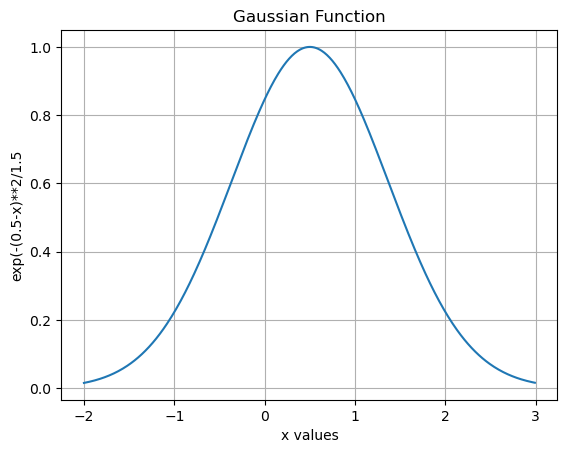

In [66]:
import matplotlib.pyplot as plt
import numpy as np

gaussian = lambda x : np.exp(-(0.5-x)**2/1.5)

x = np.arange(-2, 3, 0.01)
y = gaussian(x)

plt.figure()
plt.plot(x,y)
plt.grid()
plt.xlabel('x values')
plt.ylabel('exp(-(0.5-x)**2/1.5')
plt.title('Gaussian Function')    # For saving the figure
# plt.savefig('Gaussian.png')
plt.show()   # Not necessary in Spyder


### Customizing plots <a id="Customizing"></a>


For example:

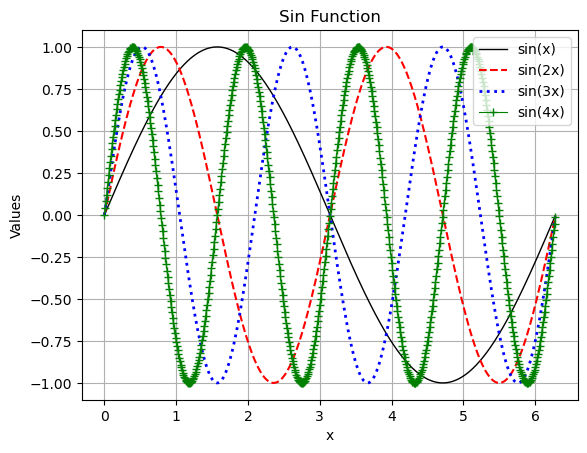

In [67]:
import matplotlib.pyplot as plt
import numpy as np

x  = np.arange(0, 2*np.pi, 0.01)
y1 = np.sin(x)
y2 = np.sin(2*x)
y3 = np.sin(3*x)
y4 = np.sin(4*x)

plt.figure()
plt.plot(x,y1, color='black', lw=1,   ls='-',  label='sin(x)')
plt.plot(x,y2, color='red',   lw=1.5, ls='--', label='sin(2x)')
plt.plot(x,y3, color='blue',  lw=2,   ls=':',  label='sin(3x)')
plt.plot(x,y4, color='green', lw=0.8, marker='+', label='sin(4x)')
plt.grid()
plt.xlabel('x')
plt.ylabel('Values')
plt.title('Sin Function')
plt.legend(loc='upper right')


The `plt.subplots()` returns the figure and **axes** handles: 

```
fig, ax = fig.subplots(args)
```

Axes handles can be used alternatively to customize a plot. For example:

Text(0.5, 1.0, 'axis labels and title example')

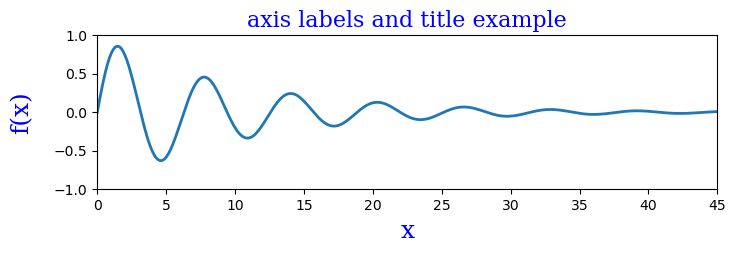

In [68]:
x = np.linspace(0, 50, 500)
y = np.sin(x) * np.exp(-x/10)

fig, ax = plt.subplots(figsize=(8, 2))
ax.plot(x, y, lw=2)
ax.set_xlim(0, 45)
ax.set_ylim(-1, 1)
ax.set_xlabel('x', labelpad=5, fontsize=18, fontname='serif', color='blue')
ax.set_ylabel('f(x)', labelpad=15, fontsize=18, fontname='serif', color='blue')
ax.set_title('axis labels and title example', fontsize=16, fontname='serif', color='blue')


### Subplots <a id="Subplots"></a>


Axes handles are particularly useful when creating multiple subplots. For example:

Text(0, 0.5, 'y')

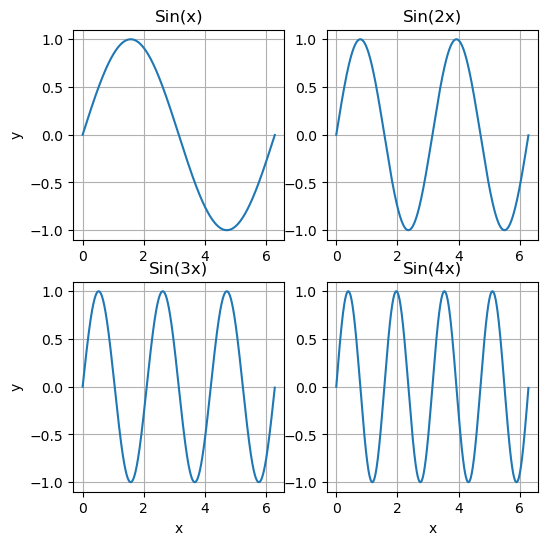

In [69]:
x  = np.arange(0, 2*np.pi, 0.01)
y1 = np.sin(x)
y2 = np.sin(2*x)
y3 = np.sin(3*x)
y4 = np.sin(4*x)

# Create a sub-plot in 2x2 layout
fig, ax = plt.subplots(2, 2, figsize=(6, 6))
                         
ax[0, 0].set_title("Sin(x)")
ax[0, 0].plot(x, y1)
ax[0, 0].grid()

ax[0, 1].set_title("Sin(2x)")
ax[0, 1].plot(x, y2)
ax[0, 1].grid()

ax[1, 0].set_title("Sin(3x)")
ax[1, 0].plot(x, y3)  
ax[1, 0].grid()

ax[1, 1].set_title("Sin(4x)")
ax[1, 1].plot(x, y4)  
ax[1, 1].grid()

ax[1, 1].set_xlabel("x")
ax[1, 0].set_xlabel("x")
ax[0, 0].set_ylabel("y")
ax[1, 0].set_ylabel("y")


## SciPy <a id="SciPy"></a>


**SciPy** is a collection of mathematical algorithms and convenience functions built on the **NumPy** extension of Python. 

### Optimization <a id="Optimization"></a>


**SciPy** sub-packages must be imported **explicitly**:

In [70]:
from scipy import optimize as opt

A central function in this module is:

```
opt.minimize(fun, x0, args=(), method=None, jac=None, hess=None, hessp=None, bounds=None, constraints=(), tol=None, callback=None, options=None)
```

As an example of **unconstrained** optimization, we find the minimum of the function:
$$
f(x) = - e^{-\left( x - 0.7 \right)^2},
$$
starting from the initial guess $x_0 = 0$. We have simply:


In [71]:
def f(x):
    return -np.exp(-(x - 0.7)**2)

x0 = 0.0
opt.minimize(f, x0)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -0.9999999999795255
        x: [ 7.000e-01]
      nit: 4
      jac: [-9.030e-06]
 hess_inv: [[ 5.023e-01]]
     nfev: 10
     njev: 5

As an example of **constrained** optimization, we find the minimum of the function:
$$
\begin{split}
f\left( x_1, x_2 \right) = & \sqrt{\left( x_1 - 3 \right)^2 + \left( x_2 - 2 \right)^2}, \\
 s.t. ~ & \left| x_1 \right| + \left| x_2 \right| \leq 1.5,
\end{split}
$$
starting from the initial guess $x_0 = \left[  0, \, 0 \right]$. We have simply:


In [72]:
def f(x):
    return np.sqrt((x[0] - 3)**2 + (x[1] - 2)**2)

def cnst(x):
    return np.atleast_1d(1.5 - np.sum(np.abs(x)))

x0 = np.array([0, 0])
opt.minimize(f, x0, constraints={"fun": cnst, "type": "ineq"})

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 2.4748737350439685
       x: [ 1.250e+00  2.500e-01]
     nit: 5
     jac: [-7.071e-01 -7.071e-01]
    nfev: 15
    njev: 5

### Signal Processing: sectral analysis <a id="Spectral"></a>


**SciPy** sub-packages for Fourier transform and signal processing are imported as:

In [73]:
from scipy import fft
from scipy import signal

As an example, we evaluate the **FFT** of a signal composed of a sum of two sinusoids and a Gaussian noise:

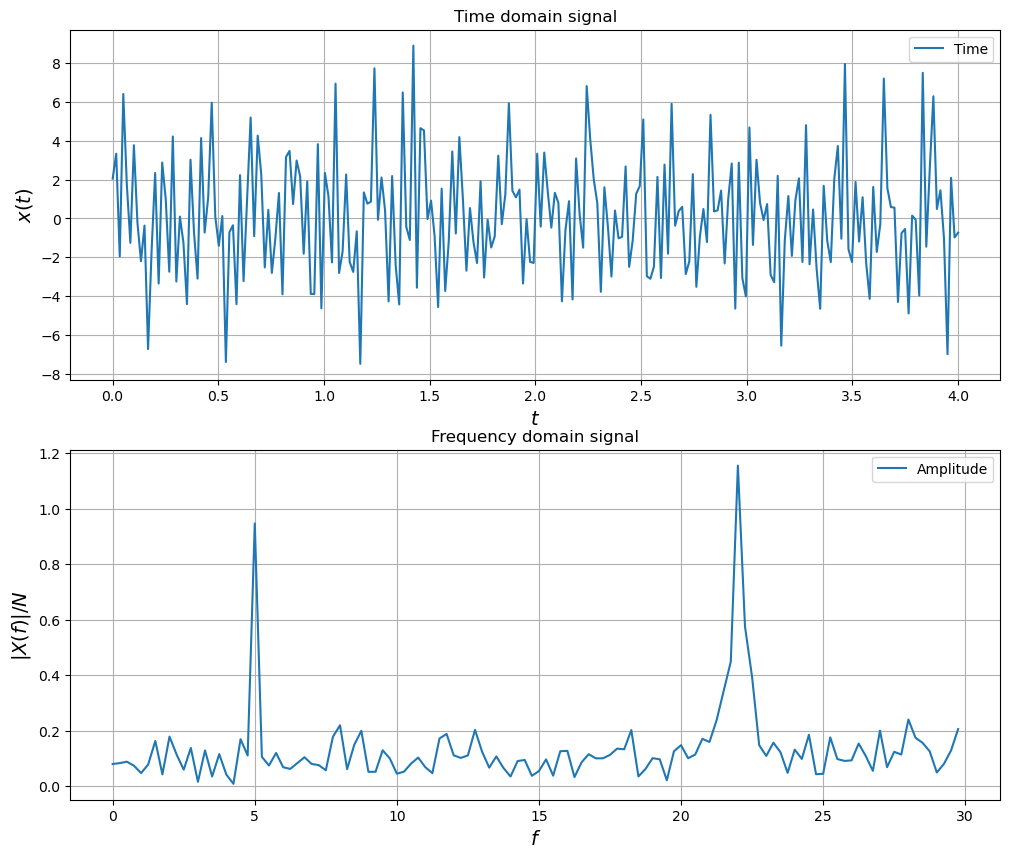

In [74]:
import numpy as np
from scipy import fft

def signal_samples(t, f1, f2):  # For signal generation
    return (2 * np.sin(2 * np.pi * f1 * t) + 3 * np.sin(2 * np.pi * f2 * t) + 2 * np.random.randn(*np.shape(t)))

Fs = 60; T = 4    # Set Fs and time interval
N = Fs*T          # Number of samples
f1 = 5; f2 = 22   # Choose f1 and f2

t = np.linspace(0, T, N)       # Generate sampled t-axes
x = signal_samples(t, f1, f2)  # Generate the signal

X = fft.fft(x)    # Evaluate the FFT

f = fft.fftfreq(N, 1.0/Fs)  # Generate the f-axis
mask = np.where(f >= 0)     # Mask for positive frequencies


fig, ax = plt.subplots(2, 1, figsize=(12, 10))
# Plot of the time-domain signal
ax[0].plot(t, x, label="Time")
ax[0].grid()
ax[0].set_title("Time domain signal")
ax[0].set_xlabel("$t$", fontsize=14)
ax[0].set_ylabel("$x(t)$", fontsize=14)
ax[0].legend()

# Plot of the frequency-domain Amplitude spectrum
ax[1].plot(f[mask], abs(X[mask])/N, label="Amplitude")
ax[1].grid()
ax[1].set_title("Frequency domain signal")
ax[1].set_xlabel("$f$", fontsize=14)
ax[1].set_ylabel("$|X(f)|/N$", fontsize=14)
ax[1].legend()

### Signal Processing: filtering <a id="Filtering"></a>


The **convolution** and the **finite difference** are implemented in **SciPy** by the following two commands:

```
y = signal.convolve(x, h)

y = signal.lfilter(b, a, x)
```

As a simple example, we generate a noisy signal, composed of the sum of two sinusoids and a Gaussian noise:

In [75]:
import numpy as np
from scipy import signal

# Function for signal generation
def signal_samples(t, f1, f2):
    return (2 * np.sin(2 * np.pi * f1 * t) + 3 * np.sin(2 * np.pi * f2 * t) + 0.5 * np.random.randn(*np.shape(t)))

# Settings
Fs = 60; T = 1
N = Fs*T
f1 = 5; f2 = 8

# Generate the noisy signal
t = np.linspace(0, T, N)
x = signal_samples(t, f1, f2)


We then **smooth** such a signal with a simple *low-pass* filter (with impulse response equal to $h = [1, 1, 1, ...]/M$):

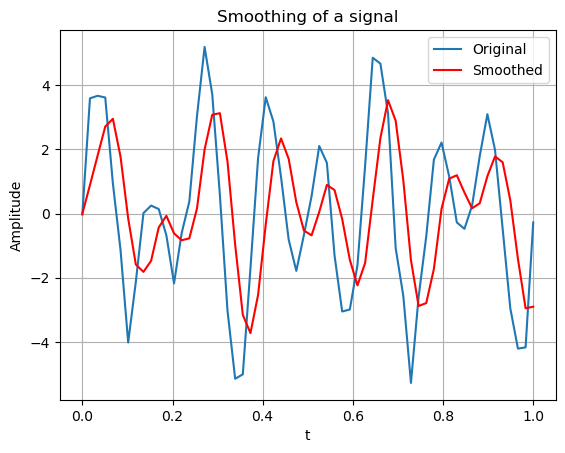

In [76]:
# Create the impulse response of a LP filter
M = 4
h = np.ones((M,))/M
y = signal.lfilter(h, 1, x)  # Filter the signal

# Plotting the original and smoothed signals
plt.figure()
plt.plot(t, x, label='Original')
plt.plot(t, y, color='red', label='Smoothed')
plt.grid()
plt.title('Smoothing of a signal')
plt.xlabel('t')
plt.ylabel('Amplitude')
plt.legend()
